# GUÍA DE LABORATORIO
## Banco de Pruebas de Procesamiento de Señales Electromagnéticas — Laboratorio Remoto PYNQ-Z2

### Experimento N° 2: Demodulación FM — Co-diseño Hardware/Software (PS ↔ PL)

---

**Plataforma:** PYNQ-Z2 (Zynq-7000, ARM Cortex-A9 dual-core + FPGA Artix-7)
**Lenguaje / entorno:** Python 3 sobre Jupyter Notebook (PYNQ)
**Duración estimada:** 3 horas (2 sesiones de laboratorio)
**Modalidad:** Laboratorio remoto
**Prerrequisito:** Experimento N° 1 (Analizador de Espectro *Waterfall*), donde se introdujo el flujo de co-diseño Vitis HLS → Vivado → *overlay* PYNQ.

---

## Índice

1. [Introducción](#1-introducción)
2. [Objetivos](#2-objetivos)
   - 2.1 [Objetivo general](#21-objetivo-general)
   - 2.2 [Objetivos específicos](#22-objetivos-específicos)
   - 2.3 [Métricas de evaluación](#23-métricas-de-evaluación)
3. [Marco teórico](#3-marco-teórico)
   - 3.1 [Modulación y demodulación FM](#31-modulación-y-demodulación-fm)
   - 3.2 [Discriminador de fase por producto conjugado (quadrature discriminator)](#32-discriminador-de-fase-por-producto-conjugado-quadrature-discriminator)
   - 3.3 [Validación numérica: RMSE contra un modelo de referencia](#33-validación-numérica-rmse-contra-un-modelo-de-referencia)
   - 3.4 [Interfaz de control AXI4-Lite en IP cores HLS](#34-interfaz-de-control-axi4-lite-en-ip-cores-hls)
4. [Materiales y configuración](#4-materiales-y-configuración)
   - 4.1 [Equipos e insumos](#41-equipos-e-insumos)
   - 4.2 [Parámetros de la señal de prueba](#42-parámetros-de-la-señal-de-prueba)
   - 4.3 [Mapa de registros del IP `fm_discriminator`](#43-mapa-de-registros-del-ip-fm_discriminator)
   - 4.4 [Requisitos previos del estudiante](#44-requisitos-previos-del-estudiante)
5. [Generación del IP Core — Vitis HLS 2022 + Vivado 2022](#5-generación-del-ip-core--vitis-hls-2022--vivado-2022)
   - 5.1 [Diseño del núcleo IP en Vitis HLS 2022](#51-diseño-del-núcleo-ip-en-vitis-hls-2022)
   - 5.2 [Integración del IP Core en Vivado 2022](#52-integración-del-ip-core-en-vivado-2022)
   - 5.3 [Generación de los archivos de overlay `.bit` y `.hwh`](#53-generación-de-los-archivos-de-overlay-bit-y-hwh)
   - 5.4 [Carga de los archivos de overlay al laboratorio remoto](#54-carga-de-los-archivos-de-overlay-al-laboratorio-remoto)
6. [Procedimiento — Benchmark cuantitativo PS vs PL](#6-procedimiento--benchmark-cuantitativo-ps-vs-pl)
7. [Análisis de resultados](#7-análisis-de-resultados)
8. [PROGRAMA - DEMODULADOR FM (versión PS)]
9. [PROGRAMA - DEMODULADOR FM (versión PL)]
10. [Conclusiones esperadas](#8-conclusiones-esperadas)
11. [Referencias sugeridas](#9-referencias-sugeridas)
12. [ANEXOS]
    - 12.1 Anexo A - fm_discriminator.h
    - 12.2 Anexo B - fm_discriminator.cpp
    - 12.3 Anexo C - test.cpp
---
 
   

## 1. INTRODUCCIÓN

La demodulación FM consiste en recuperar la señal moduladora a partir de las variaciones de frecuencia instantánea de una portadora. Cuando la señal ya está representada en banda base como una secuencia compleja IQ (como la entregada por el RTL-SDR en el Experimento N° 1), la demodulación FM puede implementarse de forma eficiente mediante un **discriminador de fase por producto conjugado** (*quadrature/complex discriminator*), que evita el cálculo explícito de derivadas o funciones trigonométricas costosas.

Al igual que en el Experimento N° 1, esta etapa de cómputo puede ejecutarse en dos dominios del SoC Zynq:

- **PS (Processing System):** el discriminador se calcula en software con NumPy (`np.angle`, producto conjugado).
- **PL (Programmable Logic):** el discriminador se implementa como un núcleo IP dedicado (`fm_discriminator`), sintetizado en Vitis HLS 2022 e integrado en Vivado 2022, accedido desde Python mediante DMA (AXI-Stream) y un banco de registros de control (AXI4-Lite).

Este experimento reutiliza la infraestructura de co-diseño HW/SW del Experimento N° 1 (mismo flujo Vitis HLS → Vivado → *overlay* PYNQ), pero incorpora un elemento nuevo: la **validación numérica cuantitativa** del resultado del hardware contra un modelo de referencia en software (RMSE), indispensable porque el discriminador FM es una etapa de demodulación cuyo error afecta directamente la calidad de la señal de audio recuperada — a diferencia de la FFT del Experimento N° 1, cuyo resultado se usaba solo con fines de visualización espectral.

---

## 2. OBJETIVOS

### 2.1 Objetivo general

Evaluar experimentalmente las ventajas del co-diseño hardware/software en un SoC Zynq (PYNQ-Z2), mediante la implementación de un discriminador de demodulación FM que se ejecuta alternativamente en el procesador (PS) y en la lógica programable (PL), cuantificando el impacto en el desempeño **y en la exactitud numérica** del sistema.

### 2.2 Objetivos específicos

1. Diseñar y sintetizar en Vitis HLS 2022 un núcleo IP de demodulación FM (`fm_discriminator`) basado en un discriminador de fase por producto conjugado.
2. Integrar el IP `fm_discriminator` en un *Block Design* de Vivado 2022, junto con un controlador DMA (AXI-Stream) y un banco de registros de control (AXI4-Lite), y generar el *overlay* (`.bit` + `.hwh`) para PYNQ.
3. Implementar el mismo discriminador de fase en **software puro (PS)** usando NumPy, como línea base (*baseline*) de referencia funcional y de desempeño.
4. Ejecutar un **benchmark cuantitativo por barrido** de tamaños de bloque `N` (1024 … 524288 muestras), comparando PS y PL en tiempo de ejecución (ToE), *throughput* y latencia por muestra.
5. Calcular el **Speedup** de PL respecto a PS para cada tamaño de bloque evaluado.
6. **Validar numéricamente** la salida del hardware frente al modelo de referencia en software mediante el **Error Cuadrático Medio (RMSE)**, evidenciando el efecto de la cuantización de punto fijo/flotante en la implementación hardware.
7. Interpretar el comportamiento de las cinco métricas (ToE, Throughput, Latencia, Speedup, RMSE) en función de `N`, relacionándolo con la arquitectura del IP y el flujo de datos DMA.

### 2.3 Métricas de evaluación

| Métrica | Descripción | Fórmula / Origen en el código |
|---|---|---|
| **ToE** (*Time of Execution*) | Tiempo de ejecución del discriminador por bloque de `N` muestras (ms) | `t_ps`, `t_pl` (medidos con `time.perf_counter()`) |
| **Throughput** | Tasa de procesamiento de muestras IQ | `N / ToE` (MSamples/s) |
| **Latencia por muestra** | Tiempo promedio de procesamiento por muestra individual | `ToE / N` (ns/muestra) |
| **Speedup** | Aceleración de PL respecto a PS, para el mismo `N` | `Speedup(N) = t_ps(N) / t_pl(N)` |
| **RMSE** | Error cuadrático medio entre la fase calculada en PL y en PS (validación numérica) | `sqrt(mean((hw − sw)²))` |

> **Nota pedagógica:** a diferencia del Experimento N° 1 (donde PS y PL usaban tamaños de FFT distintos, 8192 vs. 32768, generando una asimetría metodológica), en este experimento **ambos dominios procesan exactamente el mismo `N`** en cada iteración del barrido (`sizes`), ya que el discriminador de fase no está limitado a un tamaño de ventana fijo como el IP de FFT. Esto hace que el *speedup* de este experimento sea **directamente comparable** entre PS y PL, sin las salvedades algorítmicas discutidas en el Experimento N° 1.

---

## 3. MARCO TEÓRICO

### 3.1 Modulación y demodulación FM

En una señal FM, la información está codificada en la frecuencia instantánea de la portadora:

```
s(t) = A·cos( 2π·fc·t + 2π·kf·∫m(τ)dτ )
```

donde `m(t)` es la señal moduladora y `kf` la sensibilidad de frecuencia. Tras la conversión a banda base (mezclado y filtrado, ya realizados por el RTL-SDR en el Experimento N° 1), la señal se representa como una secuencia analítica compleja `x[n] = I[n] + jQ[n]`, cuya **fase instantánea** `φ[n] = arg(x[n])` varía proporcionalmente a `m(t)`. Demodular FM equivale entonces a estimar la **derivada discreta de la fase instantánea**.

### 3.2 Discriminador de fase por producto conjugado (*quadrature discriminator*)

En lugar de calcular `φ[n] = arg(x[n])` y luego derivar (lo cual requiere desenvolvimiento de fase o *phase unwrapping*, una operación con dependencia secuencial costosa de paralelizar en hardware), se usa el **discriminador de producto conjugado**:

```
Δφ[n] = arg( x[n] · x*[n−1] )
```

Esta expresión es matemáticamente equivalente a la diferencia de fase `φ[n] − φ[n−1]` módulo 2π, pero se calcula con una única multiplicación compleja y un `arg()` (`atan2`) por muestra, **sin necesidad de desenvolvimiento de fase**, lo que la hace ideal para una implementación en *pipeline* de hardware (alto grado de paralelismo, sin dependencias de largo alcance entre muestras salvo el retardo de una muestra). En el código de referencia (PS), esto corresponde exactamente a:

```python
phase = np.angle(iq[1:] * np.conj(iq[:-1]))
```

### 3.3 Validación numérica: RMSE contra un modelo de referencia

A diferencia de una FFT usada solo para visualización espectral (Experimento N° 1), la salida del discriminador FM representa directamente la señal demodulada (audio/datos). Por ello, este experimento incorpora una etapa de **validación numérica**: la salida del hardware (`hw = rx[1:]`) se compara muestra a muestra contra la salida de referencia en software (`phase`), calculando:

```
RMSE = sqrt( mean( (hw[:L] − phase[:L])² ) ),  L = min(len(hw), len(phase))
```

Un RMSE bajo y estable en función de `N` indica que la implementación hardware (con su precisión numérica específica — punto fijo Q15 en la entrada, salida en `float32`) reproduce fielmente el comportamiento del modelo de referencia en punto flotante de NumPy.

### 3.4 Interfaz de control AXI4-Lite en IP cores HLS

El IP `fm_discriminator` requiere, además del canal de datos AXI-Stream (igual que el IP de FFT del Experimento N° 1), un **banco de registros de control accesible por AXI4-Lite**, ya que el número de muestras `N` a procesar es un parámetro que varía en cada iteración del barrido y debe indicarse al hardware antes de iniciar cada transferencia:

```python
fm.write(0x10, N)   # registro de longitud de bloque (N)
fm.write(0x00, 1)   # registro de control: bit ap_start = 1 (inicia el cómputo)
```

Este patrón corresponde al **protocolo de control estándar generado por Vitis HLS** (`ap_ctrl_hs`) para funciones top con argumentos escalares mapeados a `s_axilite`: el registro en el offset `0x00` contiene los bits de control/estado (`ap_start`, `ap_done`, `ap_idle`, `ap_ready`), y los argumentos escalares del *top function* (como `N`) se mapean a registros subsecuentes, típicamente a partir del offset `0x10`. Este mapa de registros se detalla en la sección 4.3 y se declara explícitamente mediante *pragmas* en el diseño HLS (sección 5.1).

---

## 4. MATERIALES Y CONFIGURACIÓN

### 4.1 Equipos e insumos

| Ítem | Descripción |
|---|---|
| PYNQ-Z2 | Board con SoC Zynq-7020, acceso remoto vía Jupyter |
| Vitis HLS 2022.x | Síntesis de alto nivel del núcleo `fm_discriminator` |
| Vivado 2022.x | Integración del *Block Design*, generación de *bitstream* |
| Jupyter Notebook | Entorno de ejecución remota sobre PYNQ |

> Este experimento usa una **señal sintética** (tono complejo generado en Python) en lugar del RTL-SDR, para aislar el efecto del algoritmo de demodulación de cualquier variabilidad del canal radioeléctrico — igual que el benchmark formal del Experimento N° 1 (§7).

### 4.2 Parámetros de la señal de prueba

| Parámetro | Valor |
|---|---|
| `Fs` | 2.4 MS/s |
| `f0` | 100 kHz (desviación de tono de prueba) |
| `sizes` (barrido de `N`) | 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288 |

### 4.3 Mapa de registros del IP `fm_discriminator`

| Offset | Registro | Función |
|---|---|---|
| `0x00` | Control/estado (`ap_ctrl_hs`) | Escribir `1` en el bit 0 (`ap_start`) inicia el cómputo del bloque actual |
| `0x10` | `N` (longitud de bloque) | Número de muestras IQ a procesar en la transferencia DMA actual |

### 4.4 Requisitos previos del estudiante

- Haber completado el Experimento N° 1 (familiaridad con `pynq.Overlay`, `pynq.allocate`, `axi_dma`).
- Entorno PYNQ con `numpy`, `matplotlib` instalados.
- Overlay `design_1.bit` / `design_1.hwh` de **este** experimento cargado en el mismo directorio del notebook (ver §5.4) — **no reutilizar** el *overlay* del Experimento N° 1, ya que corresponde a un *Block Design* distinto (IP de FFT en lugar de IP de discriminador FM).
- Espacio en disco disponible para las cinco figuras `.png` generadas por el benchmark (§6, ~1 MB por figura a 300 dpi).

---

## 5. GENERACIÓN DEL IP CORE — VITIS HLS 2022 + VIVADO 2022

> Antes de poder ejecutar las celdas Python de la sección 6, es necesario generar el archivo de overlay (`design_1.bit` + `design_1.hwh`) que el PS cargará en la FPGA con el núcleo `fm_discriminator`. Este flujo lo ejecuta el estudiante en su computadora local (no en la PYNQ-Z2); solo los archivos resultantes (`.bit`/`.hwh`) se transfieren al laboratorio remoto.

### 5.1 Diseño del núcleo IP en Vitis HLS 2022

**Objetivo de esta etapa:** describir el discriminador de fase en C/C++ de alto nivel, sintetizarlo a RTL y empaquetarlo como un IP core con interfaz de datos AXI-Stream y una interfaz de control AXI4-Lite (para el parámetro `N`).

1. **Crear el proyecto HLS**
   `Vitis HLS 2022.x → File → New Component → HLS Component`. Definir:
   - *Component name*: `fm_discriminator_ip`
   - *Top Function*: `fm_discriminator` (función C/C++ que se sintetizará)
   - *Part*: `xc7z020clg400-1` (dispositivo de la PYNQ-Z2)
   - *Clock Period*: `10 ns` (100 MHz) — ajustar según margen de *timing* deseado

2. **Estructura del proyecto HLS**: para esta etapa se deben tener **tres archivos fuente**, organizados según la convención estándar de un proyecto Vitis HLS (cabecera, implementación y *testbench*):

   | Archivo | Rol | Ubicación en el proyecto |
   |---|---|---|
   | `fm_discriminator.h` | Cabecera: declaraciones, `#include`, definición de tipos (`axis_t` de entrada empaquetada I/Q, tipo de salida `float`) y prototipo de la función top `fm_discriminator` | Carpeta `Source` |
   | `fm_discriminator.cpp` | Implementación de la función top `fm_discriminator` (producto conjugado, `atan2`/`hls::atan2`, *pragmas* de interfaz AXI-Stream y AXI4-Lite) | Carpeta `Source` |
   | `test.cpp` | *Testbench* de verificación en C Simulation: genera un estímulo de prueba (tono complejo), invoca `fm_discriminator` y compara la salida contra un modelo de referencia (equivalente a `np.angle(iq[1:]*np.conj(iq[:-1]))`) | Carpeta `Test Bench` |

   La función top debe declararse como **`fm_discriminator`** en `fm_discriminator.h`/`fm_discriminator.cpp`, y ser invocada desde `test.cpp` durante la simulación en C. El prototipo debe exponer:
   - Un *stream* de entrada AXI-Stream (`s_axis`) con las muestras IQ empaquetadas (I en 16 bits bajos, Q en 16 bits altos de un `uint32`, igual que en el Experimento N° 1).
   - Un *stream* de salida AXI-Stream (`m_axis`) con la fase instantánea en `float` (coincide con `rx = allocate((N,), dtype=np.float32)` en el código Python).
   - Un argumento escalar `N` mapeado a `s_axilite`, correspondiente al registro de longitud de bloque descrito en §4.3.

   ---
   **`fm_discriminator.h`**
   ```cpp
   // ── El archivo fm_discriminator.h se encuentra en el Anexo A. ──

   ```

   ---
   **`fm_discriminator.cpp`**
   ```cpp
   // ── El archivo fm_discriminator.cpp se encuentra en el Anexo B. ──

   ```

   ---
   **`test.cpp`**
   ```cpp
   // ── El archivo test.cpp se encuentra en el Anexo C ──

   ```
   ---

   **Comentario:** a diferencia del IP de FFT del Experimento N° 1 (interfaz `ap_ctrl_none`, sin registros de control), `fm_discriminator` **sí requiere** una interfaz de control (`ap_ctrl_hs`, generada automáticamente por Vitis HLS al usar `#pragma HLS INTERFACE s_axilite port=N` y `#pragma HLS INTERFACE s_axilite port=return`), ya que `N` cambia en cada iteración del barrido de Python (§6) y debe comunicarse al hardware antes de cada transferencia DMA mediante `fm.write(0x10, N)` / `fm.write(0x00, 1)`.

3. **Simulación en C (C Simulation)**: ejecutar `test.cpp` para verificar funcionalmente `fm_discriminator` contra el modelo de referencia (`np.angle` equivalente en C/C++ o precomputado), revisando que el error numérico esperado sea consistente con la precisión de punto fijo/flotante elegida.

4. **Síntesis en C (C Synthesis)**: `Solution → Run C Synthesis` sobre la función top `fm_discriminator`. Revisar en el reporte generado:
   - Latencia estimada (ciclos de reloj) y *throughput* (Intervalo de Iniciación, II) por muestra.
   - Utilización estimada de recursos (BRAM, DSP48 — el cálculo de `atan2`/`arg` es intensivo en DSPs —, FF, LUT).

5. **Co-simulación C/RTL (C/RTL Co-simulation)**: usando `test.cpp`, valida que el RTL generado preserve el comportamiento funcional verificado en el paso 3, a nivel de ciclo de reloj.

6. **Exportar el IP (Export RTL)**: `Solution → Export RTL`, seleccionando formato **"IP Catalog"**. Esto genera un paquete `.zip` (IP-XACT) con el núcleo `fm_discriminator`, listo para ser referenciado como repositorio de IP en Vivado.

### 5.2 Integración del IP Core en Vivado 2022

**Objetivo de esta etapa:** ensamblar el sistema completo (PS + DMA + IP `fm_discriminator`) como un *Block Design*, generar el *bitstream* y exportar el hardware para PYNQ.

1. **Crear el proyecto Vivado**: `File → New Project`, seleccionando la parte `xc7z020clg400-1` (o la placa `PYNQ-Z2` si el *board file* está instalado).

2. **Añadir el repositorio de IP**: `Settings → IP → Repository → Add Repository...`, apuntando a la carpeta donde Vitis HLS exportó el paquete del paso 5.1.6. El IP `fm_discriminator_ip` debe aparecer en el catálogo de IP del proyecto.

3. **Crear el Block Design** (`Create Block Design`, p. ej. `design_1` — el nombre debe coincidir con el usado por el código Python, `Overlay("design_1.bit")`).

4. **Añadir y configurar el bloque `ZYNQ7 Processing System`**:
   - `Run Block Automation` (aplica la configuración por defecto de la placa PYNQ-Z2).
   - Habilitar el puerto `S_AXI_HP0` (High-Performance) para las transferencias DMA de alto *throughput*.

5. **Añadir el bloque `AXI Direct Memory Access` (`axi_dma_0`)**:
   - Deshabilitar *Scatter Gather Engine* (modo *Direct Register*).
   - Habilitar ambos canales: *Read Channel* (MM2S → hacia el IP `fm_discriminator`) y *Write Channel* (S2MM ← desde el IP `fm_discriminator`).
   - Configurar el ancho de datos del canal de escritura (S2MM) en **32 bits** (`float32`), coincidiendo con `rx = allocate((N,), dtype=np.float32)` del código Python.

6. **Añadir el IP `fm_discriminator`** desde el catálogo (paso 5.2.2) al *canvas* del Block Design. El bloque debe exponer, además de los puertos AXI-Stream de datos, una interfaz **AXI4-Lite** de control (visible como `s_axi_control` o similar).

7. **Conectar las interfaces AXI-Stream de datos**:
   - `axi_dma_0 / M_AXIS_MM2S` → `fm_discriminator_0 / s_axis`
   - `fm_discriminator_0 / m_axis` → `axi_dma_0 / S_AXIS_S2MM`

8. **Conectar la interfaz de control AXI4-Lite del IP**: la interfaz `s_axi_control` de `fm_discriminator_0` debe conectarse al bus de control del PS (a través de un `AXI Interconnect` / `SmartConnect` adicional, distinto del usado por `axi_dma_0`), de modo que quede mapeada en el espacio de direcciones del PS y sea accesible desde Python como `ol.fm_discriminator_0` (mismo patrón usado en el código: `fm = ol.fm_discriminator_0`).

9. **Conectar relojes y resets**: usar `Run Connection Automation` para completar automáticamente las conexiones de `FCLK_CLK0` y `processor_system_reset` faltantes.

10. **Validar el diseño**: `Tools → Validate Design` (`F6`). Corregir cualquier advertencia o error de conexión, prestando especial atención al correcto mapeo de direcciones del bloque de control (`Address Editor`).

11. **Generar el *wrapper* HDL**: clic derecho sobre `design_1` en la pestaña *Sources* → `Create HDL Wrapper` → `Let Vivado manage wrapper and auto-update`.

12. **Ejecutar el flujo de implementación**: `Run Synthesis` → `Run Implementation` → `Generate Bitstream`. Revisar el reporte de *timing* (`Timing Summary`).

### 5.3 Generación de los archivos de overlay `.bit` y `.hwh`

Una vez generado el *bitstream* exitosamente:

1. **Archivo `.bit`**: se genera en `<proyecto>.runs/impl_1/design_1_wrapper.bit`.
2. **Archivo `.hwh`**: se genera en `<proyecto>.gen/sources_1/bd/design_1/hw_handoff/design_1.hwh`. Este archivo, además de la topología AXI-Stream, describe el **mapa de direcciones del registro de control** de `fm_discriminator_0` (offsets `0x00` y `0x10` de §4.3), indispensable para que `fm.write(...)` funcione correctamente desde Python.
3. **Renombrar ambos archivos con el mismo nombre base**, coincidiendo con el usado en el código Python (`Overlay("design_1.bit")`):
   - `design_1.bit`
   - `design_1.hwh`

   > ⚠️ **Requisito crítico de PYNQ:** los dos archivos deben tener **exactamente el mismo nombre base** y residir **en la misma carpeta**. Si los nombres no coinciden o falta el `.hwh`, PYNQ no podrá resolver ni el objeto `ol.axi_dma_0` ni el objeto `ol.fm_discriminator_0`.

### 5.4 Carga de los archivos de overlay al laboratorio remoto

1. Acceder al entorno Jupyter de la PYNQ-Z2 (laboratorio remoto).
2. Ubicar la carpeta donde reside **esta guía / notebook** (el mismo directorio de trabajo donde se ejecutarán las celdas de la sección 6).
3. Usando el explorador de archivos de Jupyter (`Upload` en la barra superior del *file browser*), **cargar ambos archivos en esa misma ruta**:
   - `design_1.bit`
   - `design_1.hwh`
4. Verificar la carga correcta desde una celda del propio notebook:

In [1]:
import os
print(os.listdir())
assert "design_1.bit" in os.listdir(), "Falta design_1.bit en el directorio del notebook"
assert "design_1.hwh" in os.listdir(), "Falta design_1.hwh en el directorio del notebook"
print("Overlay listo para cargar.")

['a1_CHUNK_SEC_radio_moda_97.3MHz.wav', 'Exp2 - Guia Oficial Demodulacion FM.ipynb', 'v5_CHUNK_SEC_2_radio_moda_97.3MHz.wav', 'benchmark_fm_Speedup.png', 'benchmark_fm_RMSE.png', 'PS_CHUNK_SEC_2_radio_moda_97.3MHz.wav', 'benchmark_fm_Latency.png', 'benchmark_fm_ToE.png', 'Guia_Lab_Experimento2_DemodulacionFM_PYNQ.md', 'benchmark_fm_Throughput.png', 'Code1_DemoFM.ipynb', 'design_1.bit', 'Programa2 -  Critical Block 70 seconds.ipynb', '.ipynb_checkpoints', 'v4_CHUNK_SEC_radio_moda_97.3MHz.wav', 'design_1.hwh', 'PL_CHUNK_SEC_2_radio_moda_97.3MHz.wav']
Overlay listo para cargar.


**Comentario:** solo después de confirmar la presencia de ambos archivos en la misma carpeta del notebook se debe proceder a ejecutar la Celda 1 de la sección 6 (`Overlay("design_1.bit")`).

---

## 6. PROCEDIMIENTO — BENCHMARK CUANTITATIVO PS vs PL

> Este experimento se ejecuta como un **único flujo de benchmark** (a diferencia del Experimento N° 1, que separaba un demostrador en vivo de un benchmark formal), ya que el discriminador de fase no requiere un front-end RTL-SDR: se usa una señal sintética generada en Python para poder aislar y validar numéricamente (RMSE) el resultado del hardware.

### Celda 1 — Importaciones y carga del *overlay*

In [2]:
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt
import time

ol = Overlay("design_1.bit")

dma = ol.axi_dma_0
fm  = ol.fm_discriminator_0

print("Overlay cargado")

Overlay cargado


**Comentario:** se cargan dos objetos del *overlay*: `dma` (canal de datos AXI-Stream, igual que en el Experimento N° 1) y `fm` (interfaz de control AXI4-Lite del IP `fm_discriminator_0`, generada automáticamente por PYNQ a partir del `.hwh`, ver §5.3). El objeto `fm` permite escribir directamente en los registros mapeados en memoria descritos en §4.3 mediante `fm.write(offset, valor)`.

---

### Celda 2 — Parámetros del benchmark

In [3]:
Fs = 2.4e6
f0 = 100e3

sizes = [
    1024,
    2048,
    4096,
    8192,
    16384,
    32768,
    65536,
    131072,
    262144,
    524288
]

**Comentario:** a diferencia del Experimento N° 1 (donde el PL solo podía procesar ventanas fijas de 32768 puntos), aquí `N` es el **mismo** para PS y PL en cada iteración: el IP `fm_discriminator` no tiene una restricción de tamaño de ventana fija (procesa un *stream* continuo de longitud `N` configurable vía registro), lo cual habilita una comparación de *speedup* directa (ver nota pedagógica de §2.3).

---

### Celda 3 — Arreglos de resultados

In [4]:
toe_ps = []
toe_pl = []

throughput_ps = []
throughput_pl = []

lat_ps = []
lat_pl = []

speedup = []

rmse_list = []

**Comentario:** se acumulan cinco métricas por cada `N` del barrido: tiempo de ejecución (ToE), *throughput*, latencia por muestra, *speedup* y RMSE (validación numérica), correspondientes a los objetivos específicos 4–6 (§2.2).

---

### Celda 4 — Bucle de benchmark: señal sintética, discriminador PS y PL

In [5]:
for N in sizes:

    print("Procesando N =", N)

    # ----------------------------------------------------
    # SEÑAL SINTÉTICA (tono complejo puro a f0)
    # ----------------------------------------------------
    t = np.arange(N)
    iq = np.exp(1j*2*np.pi*f0*t/Fs)

    # ----------------------------------------------------
    # DISCRIMINADOR EN SOFTWARE (PS)
    # ----------------------------------------------------
    t0 = time.perf_counter()
    phase = np.angle(iq[1:] * np.conj(iq[:-1]))
    t_ps = time.perf_counter() - t0

    # ----------------------------------------------------
    # DISCRIMINADOR EN HARDWARE (PL)
    # ----------------------------------------------------
    I = np.int16(np.real(iq) * 32767)
    Q = np.int16(np.imag(iq) * 32767)

    tx = allocate((N,), dtype=np.uint32)
    tx[:] = (
        (Q.astype(np.uint16).astype(np.uint32) << 16)
        | I.astype(np.uint16).astype(np.uint32)
    )

    rx = allocate((N,), dtype=np.float32)

    # --- Configuración de registros de control (AXI4-Lite) ---
    fm.write(0x10, N)   # longitud de bloque
    fm.write(0x00, 1)   # ap_start

    t0 = time.perf_counter()

    dma.recvchannel.transfer(rx)
    dma.sendchannel.transfer(tx)

    dma.sendchannel.wait()
    dma.recvchannel.wait()

    t_pl = time.perf_counter() - t0

    # ----------------------------------------------------
    # VALIDACIÓN NUMÉRICA (RMSE, hardware vs. software)
    # ----------------------------------------------------
    hw = rx[1:]
    L = min(len(hw), len(phase))
    err = hw[:L] - phase[:L]
    rmse = np.sqrt(np.mean(err**2))

    # ----------------------------------------------------
    # MÉTRICAS
    # ----------------------------------------------------
    toe_ps.append(t_ps*1000)
    toe_pl.append(t_pl*1000)

    throughput_ps.append(N/t_ps/1e6)
    throughput_pl.append(N/t_pl/1e6)

    lat_ps.append(t_ps/N*1e9)
    lat_pl.append(t_pl/N*1e9)

    speedup.append(t_ps/t_pl)

    rmse_list.append(rmse)

    tx.freebuffer()
    rx.freebuffer()

Procesando N = 1024
Procesando N = 2048
Procesando N = 4096
Procesando N = 8192
Procesando N = 16384
Procesando N = 32768
Procesando N = 65536
Procesando N = 131072
Procesando N = 262144
Procesando N = 524288



**Comentario:** en cada iteración se genera el tono complejo de `N` muestras, se cronometra el discriminador en software (`np.angle(iq[1:]*np.conj(iq[:-1]))`, ecuación de §3.2) y luego el discriminador en hardware, que requiere **dos pasos adicionales previos a la transferencia DMA**: (1) empaquetar I/Q en formato Q15 dentro de un `uint32` (igual que en el Experimento N° 1) y (2) escribir los registros de control `N` y `ap_start` (§3.4) para indicarle al IP cuántas muestras procesar antes de iniciar la transferencia. Nótese que `t_pl` **solo cronometra el bloque DMA** (`transfer`/`wait`), no la escritura de registros ni el empaquetado Q15 — un punto de discusión en el análisis (§7). Finalmente, se calcula el RMSE entre `hw = rx[1:]` (salida del hardware, ya en `float32`, sin necesidad de reescalado) y `phase` (referencia software), y se liberan los buffers DMA en cada iteración.

---

### Celda 5 — Tabla resumen de resultados

In [6]:
print()
print("===========================================================")
print("                 RESULTADOS")
print("===========================================================")

print("{:>10} {:>12} {:>12} {:>12}".format(
    "Samples", "PS(ms)", "PL(ms)", "Speedup"))

for i, n in enumerate(sizes):
    print("{:10d} {:12.3f} {:12.3f} {:12.3f}".format(
        n, toe_ps[i], toe_pl[i], speedup[i]
    ))


                 RESULTADOS
   Samples       PS(ms)       PL(ms)      Speedup
      1024        2.857        1.388        2.059
      2048        1.942        0.988        1.966
      4096        2.638        0.985        2.678
      8192        5.547        1.006        5.512
     16384       11.284        1.303        8.662
     32768       24.082        1.388       17.351
     65536       46.722        1.889       24.738
    131072       95.649        2.915       32.810
    262144      193.440        5.044       38.349
    524288      380.656        9.230       41.240


**Comentario:** imprime una tabla formateada de tiempos y *speedup* por cada `N` — insumo directo para la Tabla 1 del informe (§7.1). El RMSE se reporta por separado en la Figura 5 (Celda 10); se recomienda extender esta tabla para incluir también `rmse_list` como columna adicional.

---

### Celda 6 — Figura 1: Tiempo de ejecución (ToE)

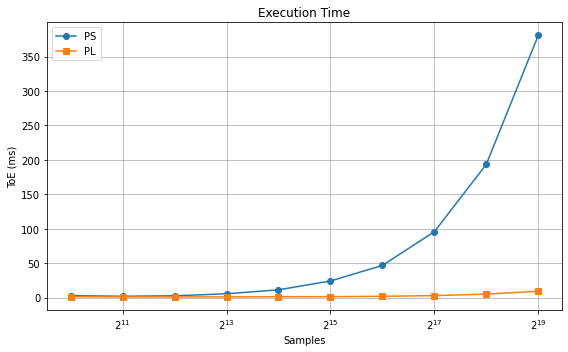

In [7]:
plt.figure(figsize=(8,5))
plt.plot(sizes, toe_ps, 'o-', label='PS')
plt.plot(sizes, toe_pl, 's-', label='PL')
plt.grid(True)
plt.xscale("log", base=2)
plt.xlabel("Samples")
plt.ylabel("ToE (ms)")
plt.title("Execution Time")
plt.legend()
plt.tight_layout()
plt.savefig("benchmark_fm_ToE.png", dpi=300)


**Comentario:** curva de tiempo absoluto de ejecución para PS y PL en función de `N`, en escala logarítmica base 2.

---

### Celda 7 — Figura 2: Throughput

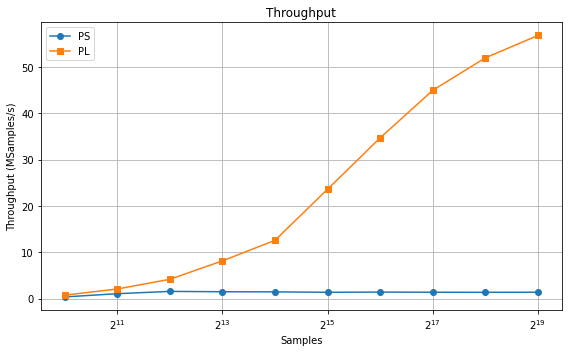

In [8]:
plt.figure(figsize=(8,5))
plt.plot(sizes, throughput_ps, 'o-', label='PS')
plt.plot(sizes, throughput_pl, 's-', label='PL')
plt.grid(True)
plt.xscale("log", base=2)
plt.xlabel("Samples")
plt.ylabel("Throughput (MSamples/s)")
plt.title("Throughput")
plt.legend()
plt.tight_layout()
plt.savefig("benchmark_fm_Throughput.png", dpi=300)


**Comentario:** curva de *throughput* (MS/s) — contraparte directa de la Figura 1.

---

### Celda 8 — Figura 3: Latencia por muestra

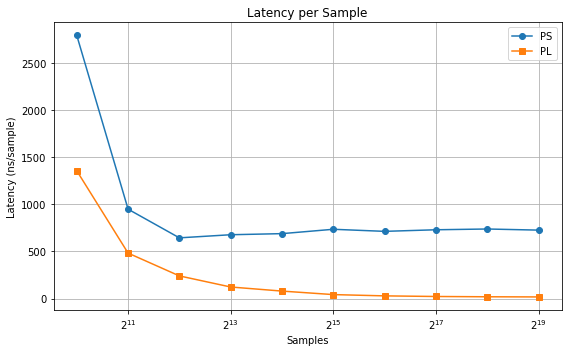

In [9]:
plt.figure(figsize=(8,5))
plt.plot(sizes, lat_ps, 'o-', label='PS')
plt.plot(sizes, lat_pl, 's-', label='PL')
plt.grid(True)
plt.xscale("log", base=2)
plt.xlabel("Samples")
plt.ylabel("Latency (ns/sample)")
plt.title("Latency per Sample")
plt.legend()
plt.tight_layout()
plt.savefig("benchmark_fm_Latency.png", dpi=300)


**Comentario:** latencia normalizada por muestra (`ToE/N` en ns), útil para observar si el *overhead* fijo (configuración de registros, arranque del DMA) domina a tamaños de bloque pequeños, y si la latencia por muestra converge a un valor asintótico a medida que `N` crece (efecto típico de *pipeline*: el costo fijo de arranque se amortiza sobre más muestras).

---

### Celda 9 — Figura 4: Speedup de hardware

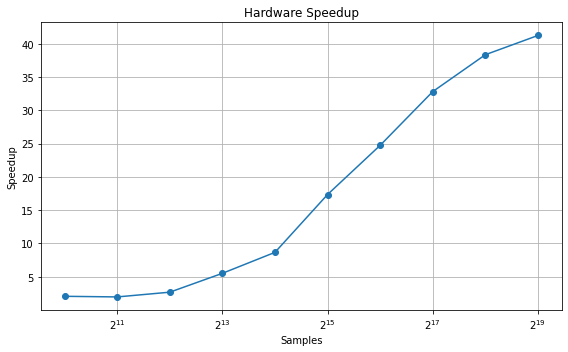

In [10]:
plt.figure(figsize=(8,5))
plt.plot(sizes, speedup, 'o-')
plt.grid(True)
plt.xscale("log", base=2)
plt.xlabel("Samples")
plt.ylabel("Speedup")
plt.title("Hardware Speedup")
plt.tight_layout()
plt.savefig("benchmark_fm_Speedup.png", dpi=300)


**Comentario:** curva de síntesis de desempeño, `Speedup(N) = t_ps(N)/t_pl(N)`. Al ser `N` idéntico entre PS y PL (§2.3), esta curva es directamente interpretable como la ganancia real del hardware, sin las salvedades algorítmicas del Experimento N° 1.

---

### Celda 10 — Figura 5: Error numérico (RMSE)

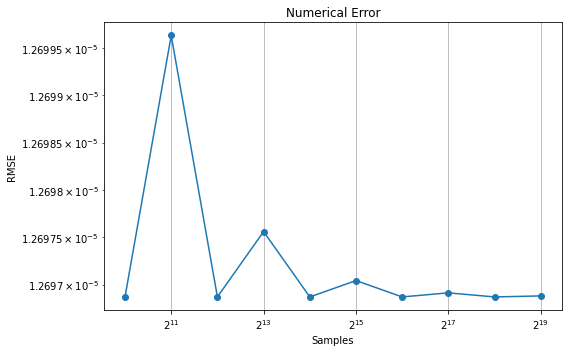


Todas las figuras fueron guardadas en:
 benchmark_fm_ToE.png
 benchmark_fm_Throughput.png
 benchmark_fm_Latency.png
 benchmark_fm_Speedup.png
 benchmark_fm_RMSE.png


In [11]:
plt.figure(figsize=(8,5))
plt.plot(sizes, rmse_list, 'o-')
plt.grid(True)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Samples")
plt.ylabel("RMSE")
plt.title("Numerical Error")
plt.tight_layout()
plt.savefig("benchmark_fm_RMSE.png", dpi=300)

plt.show()

print()
print("Todas las figuras fueron guardadas en:")
print(" benchmark_fm_ToE.png")
print(" benchmark_fm_Throughput.png")
print(" benchmark_fm_Latency.png")
print(" benchmark_fm_Speedup.png")
print(" benchmark_fm_RMSE.png")


**Comentario:** curva de RMSE en escala log-log, la métrica de **validación funcional** propia de este experimento (§3.3): confirma que la implementación hardware —con su precisión de entrada en Q15 y salida en `float32`— reproduce fielmente el discriminador de referencia en NumPy, y permite detectar si el error crece de forma anómala para algún tamaño de bloque particular (posible indicio de desbordamiento, truncamiento o error de sincronización I/Q en el diseño HLS).

---

## 7. ANÁLISIS DE RESULTADOS

### 7.1 Tabla comparativa de desempeño y exactitud numérica

Completar con los valores medidos en el barrido:

| N (muestras) | ToE PS (ms) | ToE PL (ms) | Throughput PS (MS/s) | Throughput PL (MS/s) | Latencia PS (ns/muestra) | Latencia PL (ns/muestra) | Speedup | RMSE |
|---|---|---|---|---|---|---|---|---|
| 1 024 | | | | | | | | |
| 2 048 | | | | | | | | |
| 4 096 | | | | | | | | |
| 8 192 | | | | | | | | |
| 16 384 | | | | | | | | |
| 32 768 | | | | | | | | |
| 65 536 | | | | | | | | |
| 131 072 | | | | | | | | |
| 262 144 | | | | | | | | |
| 524 288 | | | | | | | | |

Adjuntar las cinco figuras generadas: `benchmark_fm_ToE.png`, `benchmark_fm_Throughput.png`, `benchmark_fm_Latency.png`, `benchmark_fm_Speedup.png`, `benchmark_fm_RMSE.png`.

### 7.2 Preguntas de análisis

1. ¿A partir de qué tamaño de bloque `N` el *speedup* de PL supera a PS? ¿Existen tamaños pequeños de `N` donde PS sea más rápido que PL? Relacione la respuesta con el *overhead* fijo de configuración de registros (`fm.write`) y arranque de DMA, que no escala con `N`.
2. Compare la forma de la curva de *speedup* de este experimento (§6, Celda 9) con la del Experimento N° 1 (benchmark de FFT). ¿Por qué en este experimento la comparación es metodológicamente más directa (ver nota pedagógica de §2.3)?
3. Analice la curva de latencia por muestra (Celda 8): ¿a partir de qué `N` la latencia de PL se estabiliza en un valor aproximadamente constante? Interprete ese valor asintótico como el tiempo de *pipeline* por muestra del IP.
4. ¿El RMSE se mantiene aproximadamente constante en función de `N`, o presenta una tendencia (creciente/decreciente)? Relacione su respuesta con la naturaleza del discriminador (operación local, muestra a muestra, sin acumulación de error entre bloques).
5. El código actual mide `t_pl` únicamente sobre el bloque `dma.sendchannel.transfer / wait` y `dma.recvchannel.transfer / wait`. Proponga una modificación para medir por separado: (a) el tiempo de empaquetado Q15 en Python, (b) el tiempo de escritura de registros de control (`fm.write`), y (c) el tiempo de transferencia DMA en sí. ¿Cuál de estos tres esperaría que domine a `N` grande? ¿Y a `N` pequeño?
6. Explique, en términos del *pipeline* generado por Vitis HLS, por qué el discriminador de fase por producto conjugado (§3.2) es más adecuado para una implementación en hardware que un discriminador basado en `arg(x[n])` con desenvolvimiento de fase explícito.
7. ¿Qué ocurriría con el RMSE si el registro `N` escrito en `fm.write(0x10, N)` no coincidiera con el tamaño real del buffer `tx`/`rx` asignado en Python? Discuta el riesgo de desincronización entre el mapa de registros (§4.3) y el tamaño de las transferencias DMA.


---

## 8. PROGRAMA - DEMODULADOR FM (versión PS)




In [ ]:
#claude .wav
"""
WFM Demodulator — PYNQ-Z2 (CPU only)
SDR: NooElec NESDR Smart v5 via USB

Diseño anti-OOM: captura Y demodula chunk a chunk.
Nunca se acumulan los 24M muestras IQ en RAM.
Cada chunk IQ (~1.2M muestras, 9.6 MB complex128) se procesa
y se descarta antes del siguiente.

Memoria pico estimada: ~15 MB  (vs ~400 MB del enfoque previo)
"""

import numpy as np
from rtlsdr import RtlSdr
from scipy.signal import butter, sosfilt, lfilter, resample_poly, sosfilt_zi
from scipy.io.wavfile import write
import time

# ─────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────
CENTER_FREQ = 97.3e6
SAMPLE_RATE = 2.4e6
AUDIO_RATE  = 48_000
GAIN        = 33.8
DURATION    = 10
CHUNK_SEC   = 2          # 0.5 s por chunk USB ≈ 2.4 MB raw
OUTPUT_FILE = "PS_CHUNK_SEC_2_radio_moda_97.3MHz.wav"

# ─────────────────────────────────────────
# DISEÑO DE FILTROS (una sola vez)
# ─────────────────────────────────────────
FS_MID = int(SAMPLE_RATE / 10)   # 240 000 Hz  (tras decimación ÷10)
# fs final = AUDIO_RATE = 48 000 Hz (tras decimación ÷5)

# Filtro RF: pasa-bajos 100 kHz @ 2.4 MHz  (IQ complejo → orden efectivo doble)
SOS_RF    = butter(6, 100_000 / (SAMPLE_RATE / 2), btype="low", output="sos")

# Filtro audio intermedio: 15 kHz @ 240 kHz
SOS_MID   = butter(6, 15_000 / (FS_MID / 2),       btype="low", output="sos")

# Filtro audio final: 15 kHz @ 48 kHz
SOS_AUDIO = butter(6, 15_000 / (AUDIO_RATE / 2),   btype="low", output="sos")

# De-emphasis: IIR 1er orden, 75 µs
_p       = np.exp(-1.0 / (75e-6 * AUDIO_RATE))
B_DEEM   = np.array([1.0 - _p])
A_DEEM   = np.array([1.0, -_p])

def make_states():
    """Estados iniciales de los filtros (para continuidad entre chunks)."""
    from scipy.signal import sosfilt_zi, lfilter_zi
    zi_rf    = sosfilt_zi(SOS_RF)    * 0   # IQ complejo; init en 0
    zi_mid   = sosfilt_zi(SOS_MID)   * 0
    zi_audio = sosfilt_zi(SOS_AUDIO) * 0
    zi_deem  = lfilter_zi(B_DEEM, A_DEEM) * 0
    return zi_rf, zi_mid, zi_audio, zi_deem

# ─────────────────────────────────────────
# INICIALIZAR SDR
# ─────────────────────────────────────────
print("Inicializando NESDR Smart v5...")
sdr = RtlSdr()
sdr.sample_rate = SAMPLE_RATE
sdr.center_freq = CENTER_FREQ
sdr.gain        = GAIN
print(f"  Frecuencia : {CENTER_FREQ/1e6:.1f} MHz")
print(f"  Fs SDR     : {SAMPLE_RATE/1e6:.2f} Msps")
print(f"  Ganancia   : {sdr.gain} dB")

# ─────────────────────────────────────────
# CAPTURA + DSP EN STREAMING
# ─────────────────────────────────────────
chunk_samples = int(SAMPLE_RATE * CHUNK_SEC)
chunk_samples = (chunk_samples // 512) * 512
num_chunks    = int(np.ceil(DURATION / CHUNK_SEC))

print(f"\nCapturando y demodulando {DURATION} s")
print(f"  {num_chunks} chunks × {chunk_samples:,} muestras  ({chunk_samples*2/1e6:.1f} MB/chunk raw)")

zi_rf, zi_mid, zi_audio, zi_deem = make_states()
audio_chunks = []   # guardaremos float32 pequeños (480 muestras/chunk)
last_sample  = None # para el discriminador de fase entre chunks

t0 = time.perf_counter()
# ==========================================================
# BENCHMARK VARIABLES
# ==========================================================

t_capture_total      = 0.0
t_rf_total           = 0.0
t_discriminator_total= 0.0
t_decim10_total      = 0.0
t_mid_total          = 0.0
t_decim5_total       = 0.0
t_audio_total        = 0.0
t_deem_total         = 0.0

for i in range(num_chunks):
    # ── 1. Captura ──────────────────────────────────────────────────
             # complex128, ~9.6 MB
    t = time.perf_counter()

    iq = sdr.read_samples(chunk_samples)

    t_capture_total += time.perf_counter() - t
    # ── 2. Filtro RF (estado continuo entre chunks) ──────────────────
    t = time.perf_counter()

    iq, zi_rf = sosfilt(SOS_RF, iq, zi=zi_rf)

    t_rf_total += time.perf_counter() - t

    # ── 3. Discriminador FM ──────────────────────────────────────────
    if last_sample is not None:
        iq_ext = np.concatenate(([last_sample], iq))
    else:
        iq_ext = np.concatenate(([iq[0]], iq))   # primer chunk: replica primer sample
  
    t = time.perf_counter()

    fm = np.angle(iq_ext[1:] * np.conj(iq_ext[:-1]))# float64, mismo largo que iq

    t_discriminator_total += time.perf_counter() - t

    last_sample = iq[-1]
    del iq, iq_ext

    # ── 4. Decimación ÷10 (2.4 MHz → 240 kHz) ───────────────────────
    # resample_poly no acepta zi; usamos en bloques independientes.
    # El error de borde es despreciable (<0.5 ms por chunk).
    t = time.perf_counter()

    audio = resample_poly(fm,1,10).astype(np.float32)

    t_decim10_total += time.perf_counter() - t
    
    
    del fm

    # ── 5. Filtro intermedio 15 kHz @ 240 kHz ────────────────────────
    t = time.perf_counter()

    audio, zi_mid = sosfilt(SOS_MID, audio, zi=zi_mid)

    t_mid_total += time.perf_counter() - t

    # ── 6. Decimación ÷5 (240 kHz → 48 kHz) ─────────────────────────
    t = time.perf_counter()

    audio = resample_poly(audio,1,5).astype(np.float32)

    t_decim5_total += time.perf_counter() - t

    # ── 7. Filtro audio final 15 kHz @ 48 kHz ────────────────────────
    t = time.perf_counter()

    audio, zi_audio = sosfilt(SOS_AUDIO, audio, zi=zi_audio)

    t_audio_total += time.perf_counter() - t

    # ── 8. De-emphasis 75 µs ─────────────────────────────────────────
    t = time.perf_counter()

    audio, zi_deem = lfilter(B_DEEM, A_DEEM, audio, zi=zi_deem)

    t_deem_total += time.perf_counter() - t

    audio_chunks.append(audio.astype(np.float32))

    elapsed = time.perf_counter() - t0
    print(f"  Chunk {i+1:2d}/{num_chunks}  ({elapsed:.1f} s)", end="\r")

sdr.close()
print(f"\n  Completado en {time.perf_counter()-t0:.2f} s")

# ─────────────────────────────────────────
# ENSAMBLADO FINAL (solo audio, ~480k muestras float32 ≈ 1.8 MB)
# ─────────────────────────────────────────
print("Ensamblando audio...")
audio = np.concatenate(audio_chunks).astype(np.float64)
del audio_chunks

# DC offset
audio -= np.mean(audio)

# Normalización robusta
peak = np.percentile(np.abs(audio), 99.9)
audio = np.clip(audio / (peak + 1e-12), -1.0, 1.0)

# ==========================================================
# PERFORMANCE REPORT
# ==========================================================

processing_time = (
    t_capture_total +
    t_rf_total +
    t_discriminator_total +
    t_decim10_total +
    t_mid_total +
    t_decim5_total +
    t_audio_total +
    t_deem_total
)

throughput = (chunk_samples * num_chunks) / processing_time / 1e6

latency_sample = processing_time / (chunk_samples * num_chunks) * 1e6

real_time_factor = DURATION / processing_time

print("\n")
print("="*70)
print("             WFM DEMODULATION BENCHMARK WITH FM DISCRIMINATOR IN PS")
print("="*70)

print(f"{'Stage':35s}{'ToE (ms)':>12s}{'ToE (%)':>12s}")

print("-"*70)

stages = [
    ("USB Capture",          t_capture_total),
    ("RF Lowpass Filter",    t_rf_total),
    ("FM Discriminator",     t_discriminator_total),
    ("Decimation x10",       t_decim10_total),
    ("Intermediate Filter",  t_mid_total),
    ("Decimation x5",        t_decim5_total),
    ("Audio Filter",         t_audio_total),
    ("De-emphasis",          t_deem_total)
]

for name, value in stages:

    print(
        f"{name:35s}"
        f"{value*1000:12.2f}"
        f"{100*value/processing_time:12.2f}"
    )

print("-"*70)

print(f"{'TOTAL':35s}{processing_time*1000:12.2f}{100.0:12.2f}")

print("\n")
print(f"Processed IQ Samples      : {chunk_samples*num_chunks:,}")
print(f"Audio Samples             : {len(audio):,}")
print(f"Throughput                : {throughput:.2f} MSamples/s")
print(f"Latency / IQ Sample       : {latency_sample:.3f} us")
print(f"Real-Time Factor (RTF)    : {real_time_factor:.2f} x")
print(f"Processing Time           : {processing_time:.3f} s")
print(f"Recording Time            : {DURATION:.3f} s")

print("="*70)


# ─────────────────────────────────────────
# GUARDAR WAV
# ─────────────────────────────────────────
duration_real = len(audio) / AUDIO_RATE
print(f"Duración real : {duration_real:.3f} s")
write(OUTPUT_FILE, AUDIO_RATE, (audio * 32767).astype(np.int16))
print(f"Guardado      : {OUTPUT_FILE}")

---

## 9. PROGRAMA - DEMODULADOR FM (versión PL)

In [ ]:
#claude .wav
"""
WFM Demodulator — PYNQ-Z2 (CPU only)
SDR: NooElec NESDR Smart v5 via USB

Diseño anti-OOM: captura Y demodula chunk a chunk.
Nunca se acumulan los 24M muestras IQ en RAM.
Cada chunk IQ (~1.2M muestras, 9.6 MB complex128) se procesa
y se descarta antes del siguiente.

Memoria pico estimada: ~15 MB  (vs ~400 MB del enfoque previo)
"""

import numpy as np
from rtlsdr import RtlSdr
from scipy.signal import butter, sosfilt, lfilter, resample_poly, sosfilt_zi
from scipy.io.wavfile import write
import time

from pynq import Overlay, allocate

# ==========================================================
# LOAD OVERLAY
# ==========================================================

ol = Overlay("design_1.bit")

dma = ol.axi_dma_0
fm  = ol.fm_discriminator_0

print("FM Discriminator HW listo.")

# ─────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────
CENTER_FREQ = 97.3e6
SAMPLE_RATE = 2.4e6
AUDIO_RATE  = 48_000
GAIN        = 33.8
DURATION    = 10
CHUNK_SEC   = 2          # 0.5 s por chunk USB ≈ 2.4 MB raw
OUTPUT_FILE = "PL_CHUNK_SEC_2_radio_moda_97.3MHz.wav"

# ─────────────────────────────────────────
# DISEÑO DE FILTROS (una sola vez)
# ─────────────────────────────────────────
FS_MID = int(SAMPLE_RATE / 10)   # 240 000 Hz  (tras decimación ÷10)
# fs final = AUDIO_RATE = 48 000 Hz (tras decimación ÷5)

# Filtro RF: pasa-bajos 100 kHz @ 2.4 MHz  (IQ complejo → orden efectivo doble)
SOS_RF    = butter(6, 100_000 / (SAMPLE_RATE / 2), btype="low", output="sos")

# Filtro audio intermedio: 15 kHz @ 240 kHz
SOS_MID   = butter(6, 15_000 / (FS_MID / 2),       btype="low", output="sos")

# Filtro audio final: 15 kHz @ 48 kHz
SOS_AUDIO = butter(6, 15_000 / (AUDIO_RATE / 2),   btype="low", output="sos")

# De-emphasis: IIR 1er orden, 75 µs
_p       = np.exp(-1.0 / (75e-6 * AUDIO_RATE))
B_DEEM   = np.array([1.0 - _p])
A_DEEM   = np.array([1.0, -_p])

def make_states():
    """Estados iniciales de los filtros (para continuidad entre chunks)."""
    from scipy.signal import sosfilt_zi, lfilter_zi
    zi_rf    = sosfilt_zi(SOS_RF)    * 0   # IQ complejo; init en 0
    zi_mid   = sosfilt_zi(SOS_MID)   * 0
    zi_audio = sosfilt_zi(SOS_AUDIO) * 0
    zi_deem  = lfilter_zi(B_DEEM, A_DEEM) * 0
    return zi_rf, zi_mid, zi_audio, zi_deem

# ─────────────────────────────────────────
# INICIALIZAR SDR
# ─────────────────────────────────────────
print("Inicializando NESDR Smart v5...")
sdr = RtlSdr()
sdr.sample_rate = SAMPLE_RATE
sdr.center_freq = CENTER_FREQ
sdr.gain        = GAIN
print(f"  Frecuencia : {CENTER_FREQ/1e6:.1f} MHz")
print(f"  Fs SDR     : {SAMPLE_RATE/1e6:.2f} Msps")
print(f"  Ganancia   : {sdr.gain} dB")

# ─────────────────────────────────────────
# CAPTURA + DSP EN STREAMING
# ─────────────────────────────────────────
chunk_samples = int(SAMPLE_RATE * CHUNK_SEC)
chunk_samples = (chunk_samples // 512) * 512
num_chunks    = int(np.ceil(DURATION / CHUNK_SEC))

print(f"\nCapturando y demodulando {DURATION} s")
print(f"  {num_chunks} chunks × {chunk_samples:,} muestras  ({chunk_samples*2/1e6:.1f} MB/chunk raw)")

zi_rf, zi_mid, zi_audio, zi_deem = make_states()
audio_chunks = []   # guardaremos float32 pequeños (480 muestras/chunk)
last_sample  = None # para el discriminador de fase entre chunks

t0 = time.perf_counter()
# ==========================================================
# BENCHMARK VARIABLES
# ==========================================================

t_capture_total      = 0.0
t_rf_total           = 0.0
t_discriminator_total= 0.0
t_decim10_total      = 0.0
t_mid_total          = 0.0
t_decim5_total       = 0.0
t_audio_total        = 0.0
t_deem_total         = 0.0

for i in range(num_chunks):
    # ── 1. Captura ──────────────────────────────────────────────────
             # complex128, ~9.6 MB
    t = time.perf_counter()

    iq = sdr.read_samples(chunk_samples)

    t_capture_total += time.perf_counter() - t
    # ── 2. Filtro RF (estado continuo entre chunks) ──────────────────
    t = time.perf_counter()

    iq, zi_rf = sosfilt(SOS_RF, iq, zi=zi_rf)

    t_rf_total += time.perf_counter() - t

   


    # ==========================================================
    # -- 3 FM DISCRIMINATOR (PL)
    # Procesamiento por bloques DMA
    # ==========================================================

    BLOCK_SIZE = 32768

    fm_signal = np.empty(chunk_samples, dtype=np.float32)

    t = time.perf_counter()

    for start in range(0, chunk_samples, BLOCK_SIZE):

        end = min(start + BLOCK_SIZE, chunk_samples)

        block_len = end - start

        iq_block = iq[start:end]

        # ---------------------------------------------
        # Conversión IQ -> Q15
        # ---------------------------------------------
        I = np.int16(np.real(iq_block) * 32767)

        Q = np.int16(np.imag(iq_block) * 32767)

        tx = allocate(shape=(block_len,), dtype=np.uint32)

        tx[:] = (
            (Q.astype(np.uint16).astype(np.uint32) << 16)
            |
            I.astype(np.uint16).astype(np.uint32)
        )

        rx = allocate(shape=(block_len,), dtype=np.float32)

        # ---------------------------------------------
        # Ejecutar IP
        # ---------------------------------------------
        fm.write(0x10, block_len)
        fm.write(0x00, 0x01)

        dma.recvchannel.transfer(rx)
        dma.sendchannel.transfer(tx)

        dma.sendchannel.wait()
        dma.recvchannel.wait()

        fm_signal[start:end] = rx

        tx.freebuffer()
        rx.freebuffer()

    t_discriminator_total += time.perf_counter() - t

    last_sample = iq[-1]

    del iq

    # ── 4. Decimación ÷10 (2.4 MHz → 240 kHz) ───────────────────────
    # resample_poly no acepta zi; usamos en bloques independientes.
    # El error de borde es despreciable (<0.5 ms por chunk).
    t = time.perf_counter()

    audio = resample_poly(fm_signal,1,10).astype(np.float32)

    t_decim10_total += time.perf_counter() - t
    
    
    del fm_signal

    # ── 5. Filtro intermedio 15 kHz @ 240 kHz ────────────────────────
    t = time.perf_counter()

    audio, zi_mid = sosfilt(SOS_MID, audio, zi=zi_mid)

    t_mid_total += time.perf_counter() - t

    # ── 6. Decimación ÷5 (240 kHz → 48 kHz) ─────────────────────────
    t = time.perf_counter()

    audio = resample_poly(audio,1,5).astype(np.float32)

    t_decim5_total += time.perf_counter() - t

    # ── 7. Filtro audio final 15 kHz @ 48 kHz ────────────────────────
    t = time.perf_counter()

    audio, zi_audio = sosfilt(SOS_AUDIO, audio, zi=zi_audio)

    t_audio_total += time.perf_counter() - t

    # ── 8. De-emphasis 75 µs ─────────────────────────────────────────
    t = time.perf_counter()

    audio, zi_deem = lfilter(B_DEEM, A_DEEM, audio, zi=zi_deem)

    t_deem_total += time.perf_counter() - t

    audio_chunks.append(audio.astype(np.float32))

    elapsed = time.perf_counter() - t0
    print(f"  Chunk {i+1:2d}/{num_chunks}  ({elapsed:.1f} s)", end="\r")

sdr.close()
print(f"\n  Completado en {time.perf_counter()-t0:.2f} s")

# ─────────────────────────────────────────
# ENSAMBLADO FINAL (solo audio, ~480k muestras float32 ≈ 1.8 MB)
# ─────────────────────────────────────────
print("Ensamblando audio...")
audio = np.concatenate(audio_chunks).astype(np.float64)
del audio_chunks

# DC offset
audio -= np.mean(audio)

# Normalización robusta
peak = np.percentile(np.abs(audio), 99.9)
audio = np.clip(audio / (peak + 1e-12), -1.0, 1.0)

# ==========================================================
# PERFORMANCE REPORT
# ==========================================================

processing_time = (
    t_capture_total +
    t_rf_total +
    t_discriminator_total +
    t_decim10_total +
    t_mid_total +
    t_decim5_total +
    t_audio_total +
    t_deem_total
)

throughput = (chunk_samples * num_chunks) / processing_time / 1e6

latency_sample = processing_time / (chunk_samples * num_chunks) * 1e6

real_time_factor = DURATION / processing_time

print("\n")
print("="*70)
print("             WFM DEMODULATION BENCHMARK WITH FM DISCRIMINATOR IN PL")
print("="*70)

print(f"{'Stage':35s}{'ToE (ms)':>12s}{'ToE (%)':>12s}")

print("-"*70)

stages = [
    ("USB Capture",          t_capture_total),
    ("RF Lowpass Filter",    t_rf_total),
    ("FM Discriminator",     t_discriminator_total),
    ("Decimation x10",       t_decim10_total),
    ("Intermediate Filter",  t_mid_total),
    ("Decimation x5",        t_decim5_total),
    ("Audio Filter",         t_audio_total),
    ("De-emphasis",          t_deem_total)
]

for name, value in stages:

    print(
        f"{name:35s}"
        f"{value*1000:12.2f}"
        f"{100*value/processing_time:12.2f}"
    )

print("-"*70)

print(f"{'TOTAL':35s}{processing_time*1000:12.2f}{100.0:12.2f}")

print("\n")
print(f"Processed IQ Samples      : {chunk_samples*num_chunks:,}")
print(f"Audio Samples             : {len(audio):,}")
print(f"Throughput                : {throughput:.2f} MSamples/s")
print(f"Latency / IQ Sample       : {latency_sample:.3f} us")
print(f"Real-Time Factor (RTF)    : {real_time_factor:.2f} x")
print(f"Processing Time           : {processing_time:.3f} s")
print(f"Recording Time            : {DURATION:.3f} s")

print("="*70)


# ─────────────────────────────────────────
# GUARDAR WAV
# ─────────────────────────────────────────
duration_real = len(audio) / AUDIO_RATE
print(f"Duración real : {duration_real:.3f} s")
write(OUTPUT_FILE, AUDIO_RATE, (audio * 32767).astype(np.int16))
print(f"Guardado      : {OUTPUT_FILE}")


---

## 10. CONCLUSIONES ESPERADAS

Al finalizar el experimento, el estudiante debe ser capaz de:

- Diseñar un IP core con interfaz mixta (datos por AXI-Stream, control por AXI4-Lite) en Vitis HLS 2022, e integrarlo en un *Block Design* de Vivado 2022 junto con un controlador DMA.
- Cuantificar, con datos propios, el *speedup* de una etapa de demodulación FM al migrarla del procesador a la lógica programable, bajo una metodología de comparación directa (mismo `N` en ambos dominios).
- Validar numéricamente una implementación hardware mediante RMSE contra un modelo de referencia en software, reconociendo que — a diferencia de una FFT usada solo para visualización — un discriminador de demodulación exige verificación de exactitud, no solo de velocidad.
- Relacionar el comportamiento de la latencia por muestra con los conceptos de *pipeline*, latencia de arranque (*startup latency*) y throughput en estado estable de un IP HLS.
- Identificar y proponer instrumentación adicional (medición desagregada de tiempos) para aislar el *overhead* de configuración de registros del tiempo de cómputo puro en el hardware.

---

## 11. REFERENCIAS SUGERIDAS

- Xilinx/AMD. *Vitis HLS User Guide (UG1399)* — interfaces `s_axilite`, `ap_ctrl_hs`, `axis`.
- Xilinx/AMD. *Zynq-7000 SoC Technical Reference Manual.*
- PYNQ Documentation. *pynq.Overlay, pynq.allocate, MMIO/registros de control.* (http://pynq.readthedocs.io)
- Lyons, R. G. *Understanding Digital Signal Processing* — discriminadores de FM, demodulación por producto conjugado.
- Oppenheim, A. V.; Schafer, R. W. *Discrete-Time Signal Processing* — señales analíticas y fase instantánea.

---

*Guía elaborada para el Banco de Pruebas de Procesamiento de Señales Electromagnéticas — Laboratorio Remoto PYNQ-Z2.*

---

## 12. ANEXOS
### 12.1 Anexo A - fm_discriminator.h

In [ ]:
#ifndef FM_DISCRIMINATOR_H
#define FM_DISCRIMINATOR_H

#include <ap_int.h>
#include <hls_stream.h>
#include <hls_math.h>
#include <ap_axi_sdata.h>

typedef ap_axiu<32,0,0,0> axis_t;

void fm_discriminator(
    hls::stream<axis_t> &s_axis,
    hls::stream<axis_t> &m_axis,
    int length
);

#endif


### 12.2 Anexo B - fm_discriminator.cpp

In [ ]:
#include "fm_discriminator.h"

void fm_discriminator(
        hls::stream<axis_t> &s_axis,
        hls::stream<axis_t> &m_axis,
        int length)
{

#pragma HLS INTERFACE axis port=s_axis
#pragma HLS INTERFACE axis port=m_axis

#pragma HLS INTERFACE s_axilite port=length
#pragma HLS INTERFACE s_axilite port=return

#pragma HLS PIPELINE II=1

    static ap_int<16> I_prev = 0;
    static ap_int<16> Q_prev = 0;

    bool first = true;

    for(int i=0;i<length;i++)
    {

#pragma HLS PIPELINE II=1

        axis_t din = s_axis.read();

        ap_uint<32> word = din.data;

        ap_int<16> I = word.range(15,0);
        ap_int<16> Q = word.range(31,16);

        float out=0;

        if(first)
        {
            first=false;
        }
        else
        {

            float re =
                (float)I*(float)I_prev +
                (float)Q*(float)Q_prev;

            float im =
                (float)I_prev*(float)Q -
                (float)Q_prev*(float)I;

            out = hls::atan2f(im,re);

        }

        union{
            float f;
            unsigned int u;
        } conv;

        conv.f=out;

        axis_t dout;

        dout.data=conv.u;
        dout.keep=-1;
        dout.strb=-1;
        dout.last=din.last;

        m_axis.write(dout);

        I_prev=I;
        Q_prev=Q;
    }
}


### 12.3 Anexo C - test.cpp

In [ ]:
#include "fm_discriminator.h"

#include <iostream>
#include <cmath>

using namespace std;

int main()
{

    hls::stream<axis_t> input;
    hls::stream<axis_t> output;

    const int N=64;

    double Fs=2.4e6;
    double f0=100e3;

    for(int n=0;n<N;n++)
    {

        double phase=2*M_PI*f0*n/Fs;

        short I=(short)(32767*cos(phase));
        short Q=(short)(32767*sin(phase));

        axis_t sample;

        sample.data=((unsigned short)Q<<16) |
                    ((unsigned short)I);

        sample.keep=-1;
        sample.strb=-1;
        sample.last=(n==N-1);

        input.write(sample);

    }

    fm_discriminator(input,output,N);

    cout<<"Output:\n";

    for(int i=0;i<N;i++)
    {

        axis_t word=output.read();

        union{

            unsigned int u;
            float f;

        } conv;

        conv.u=word.data;

        cout<<i<<"  "<<conv.f<<endl;

    }

    return 0;
}
